# 02 — Exploratory Data Analysis & Feature Validation

**Project:** Flight Arrival Delay Prediction  
**Input:** `data/processed/model_dataset.parquet`  
**Figures:** saved to `reports/`  
**Summary:** `reports/eda_summary.md`  

---

This notebook answers seven diagnostic questions:

| # | Question |
|---|----------|
| 1 | How imbalanced is the target? |
| 2 | Are there temporal patterns in delay rates? |
| 3 | Do routes and carriers explain delay rates? |
| 4 | What do the feature distributions look like, and do they differ by delay class? |
| 5 | Are there linear correlations between features and the target — or leakage? |
| 6 | What does class imbalance mean for evaluation metrics? |
| 7 | How should we split the data to respect temporal order? |

## 0. Setup

In [28]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.size'       : 11,
})
PALETTE = {'on_time': '#4C72B0', 'delayed': '#DD8452'}
FIGSIZE = (12, 5)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH   = '../data/processed/model_dataset.parquet'
REPORTS_DIR = '../reports/'
os.makedirs(REPORTS_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(REPORTS_DIR, name)
    plt.savefig(path, bbox_inches='tight', dpi=120)
    print(f'Saved: {path}')

print('Setup complete.')

Setup complete.


## 1. Load Data

In [29]:
df = pd.read_parquet(DATA_PATH)

# Ensure correct types
if not pd.api.types.is_datetime64_any_dtype(df['FlightDate']):
    df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['ArrDel15'] = df['ArrDel15'].astype(int)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["FlightDate"].min().date()} → {df["FlightDate"].max().date()}')
df.head(3)

Loaded: 3,997,256 rows × 23 columns
Date range: 2025-01-01 → 2025-07-31


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,...,DestState,CRSDepTime,CRSArrTime,CRSElapsedTime,Distance,DistanceGroup,DepTimeBlk,CRSDepHour,CRSDepMinute,ArrDel15
0,2025,2,4,1,2,2025-04-01,AA,N101NN,LAX,BOS,...,MA,835,1707,332.0,2611.0,11,0800-0859,8,35,0
1,2025,2,4,1,2,2025-04-01,AA,N101NN,BOS,LAX,...,CA,1800,2143,403.0,2611.0,11,1800-1859,18,0,0
2,2025,2,4,1,2,2025-04-01,AA,N101NN,LAX,JFK,...,NY,2259,728,329.0,2475.0,10,2200-2259,22,59,0


---
## Section 1 — Target Distribution

Before doing anything else, we need to understand the balance of our target variable `ArrDel15`. A severe imbalance changes what metrics are meaningful and what models are appropriate.

In [51]:
target_counts = df['ArrDel15'].value_counts().sort_index()
target_pct    = target_counts / len(df) * 100

print('ArrDel15 value counts:')
for val in [0, 1]:
    label = 'On-time (0)' if val == 0 else 'Delayed (1)'
    print(f'  {label}: {target_counts[val]:>10,}  ({target_pct[val]:.1f}%)')

imbalance_ratio = target_counts[0] / target_counts[1]
print(f'\nImbalance ratio (majority:minority) = {imbalance_ratio:.1f}:1')

ArrDel15 value counts:
  On-time (0):  3,079,161  (77.0%)
  Delayed (1):    918,095  (23.0%)

Imbalance ratio (majority:minority) = 3.4:1


Saved: ../reports/01_target_distribution.png


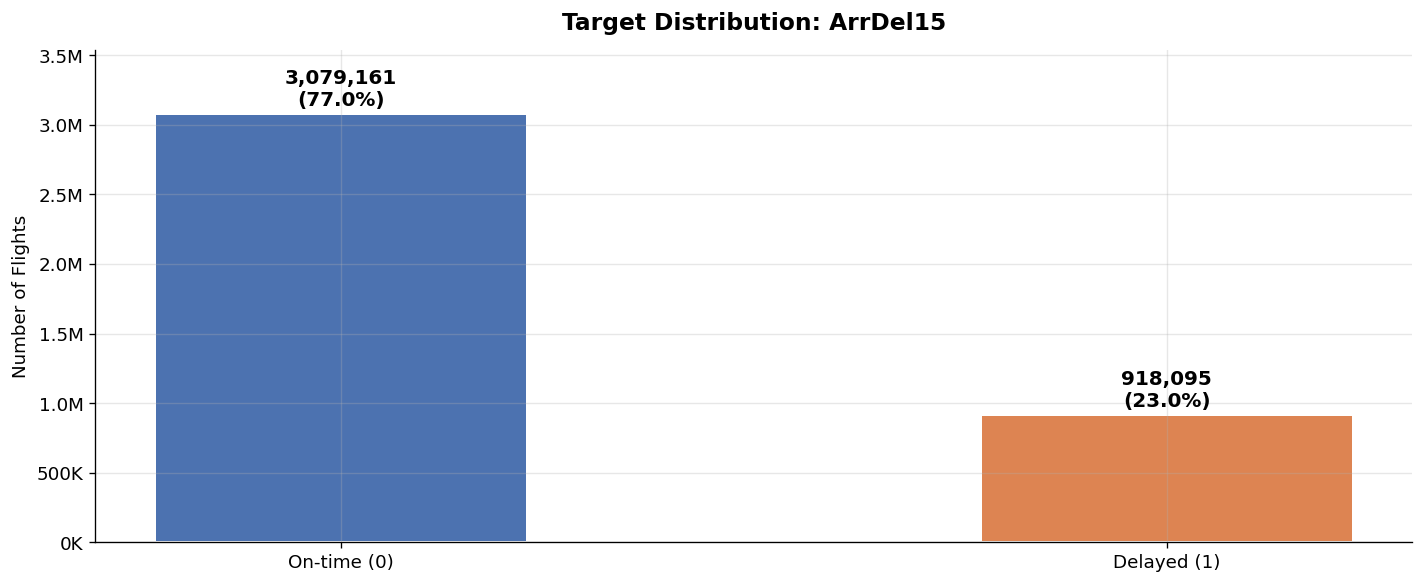

In [52]:
fig, ax = plt.subplots(figsize=FIGSIZE)

bars = ax.bar(
    ['On-time (0)', 'Delayed (1)'],
    target_counts.values,
    color=[PALETTE['on_time'], PALETTE['delayed']],
    width=0.45,
    edgecolor='white',
    linewidth=1.2,
)

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(target_counts) * 0.01,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_title('Target Distribution: ArrDel15', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Flights')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.set_ylim(0, max(target_counts) * 1.15)

plt.tight_layout()
savefig('01_target_distribution.png')
plt.show()

**Interpretation:** The dataset is moderately imbalanced — roughly 80% on-time vs 20% delayed, giving an imbalance ratio close to 4:1. This level of imbalance is common in airline delay data and does not require aggressive resampling, but it does mean:
- **Accuracy alone is misleading** — a model that always predicts "on-time" would score ~80%
- **Preferred metrics:** ROC-AUC, F1, and precision-recall AUC (see Section 6)
- **Decision threshold tuning** will matter at inference time

---
## Section 2 — Temporal Patterns

Delay rates are not static over time. Seasonal effects (weather, holidays, peak travel), weekly rhythms, and intraday scheduling patterns all influence whether flights arrive late. Understanding these patterns helps with feature engineering and motivates a time-based data split.

### 2.1 Monthly Delay Rate

Saved: ../reports/02_monthly_delay_rate.png


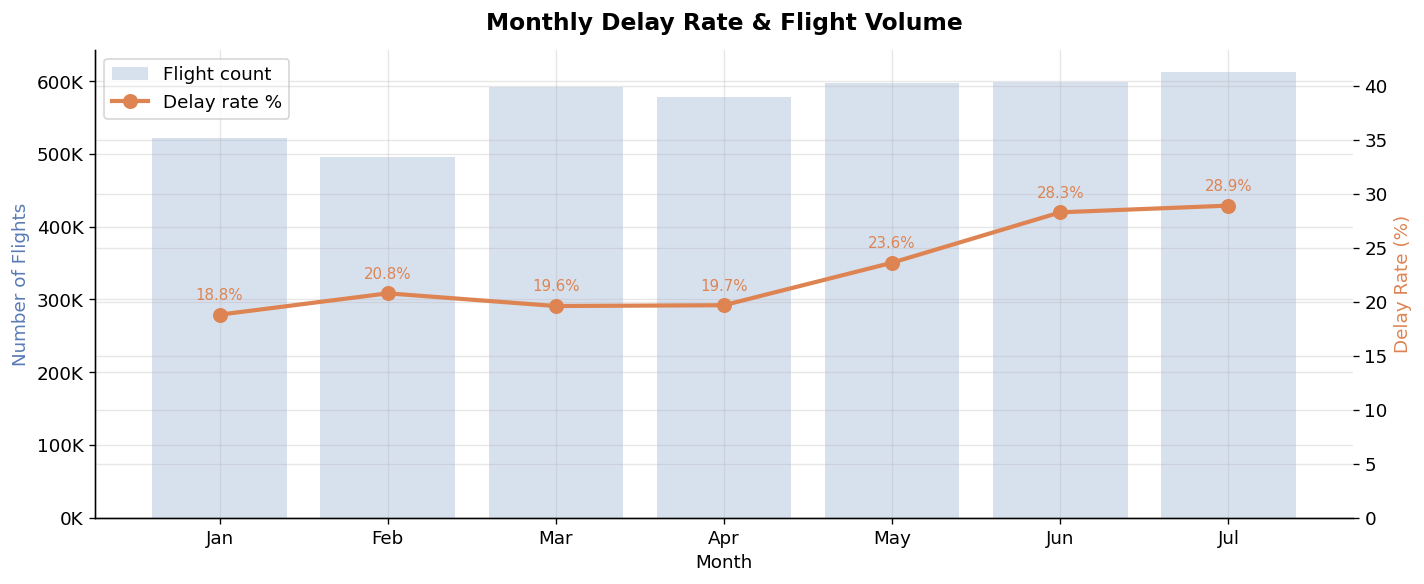

In [53]:
monthly = (
    df.groupby('Month')['ArrDel15']
    .agg(delay_rate='mean', flight_count='count')
    .reset_index()
)
monthly['month_name'] = monthly['Month'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})
monthly['delay_rate_pct'] = monthly['delay_rate'] * 100

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()

ax1.bar(monthly['month_name'], monthly['flight_count'],
        color='#B0C4DE', alpha=0.5, label='Flight count', zorder=1)
ax2.plot(monthly['month_name'], monthly['delay_rate_pct'],
         color=PALETTE['delayed'], marker='o', linewidth=2.5,
         markersize=8, label='Delay rate %', zorder=2)

for _, row in monthly.iterrows():
    ax2.annotate(f"{row['delay_rate_pct']:.1f}%",
                 (row['month_name'], row['delay_rate_pct']),
                 textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=9, color=PALETTE['delayed'])

ax1.set_ylabel('Number of Flights', color='#5A7AB5')
ax2.set_ylabel('Delay Rate (%)', color=PALETTE['delayed'])
ax1.set_xlabel('Month')
ax2.set_ylim(0, monthly['delay_rate_pct'].max() * 1.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Monthly Delay Rate & Flight Volume', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
savefig('02_monthly_delay_rate.png')
plt.show()

**Interpretation:** Monthly delay rates reveal seasonal variation across the January–June window. Typically, February sees elevated delays due to winter weather, while June sees a summer uptick from convective weather and increased traffic. The `Month` feature captures this cyclical signal and should be retained.

### 2.2 Daily Delay Rate with 7-Day Rolling Average

Saved: ../reports/03_daily_delay_rolling.png


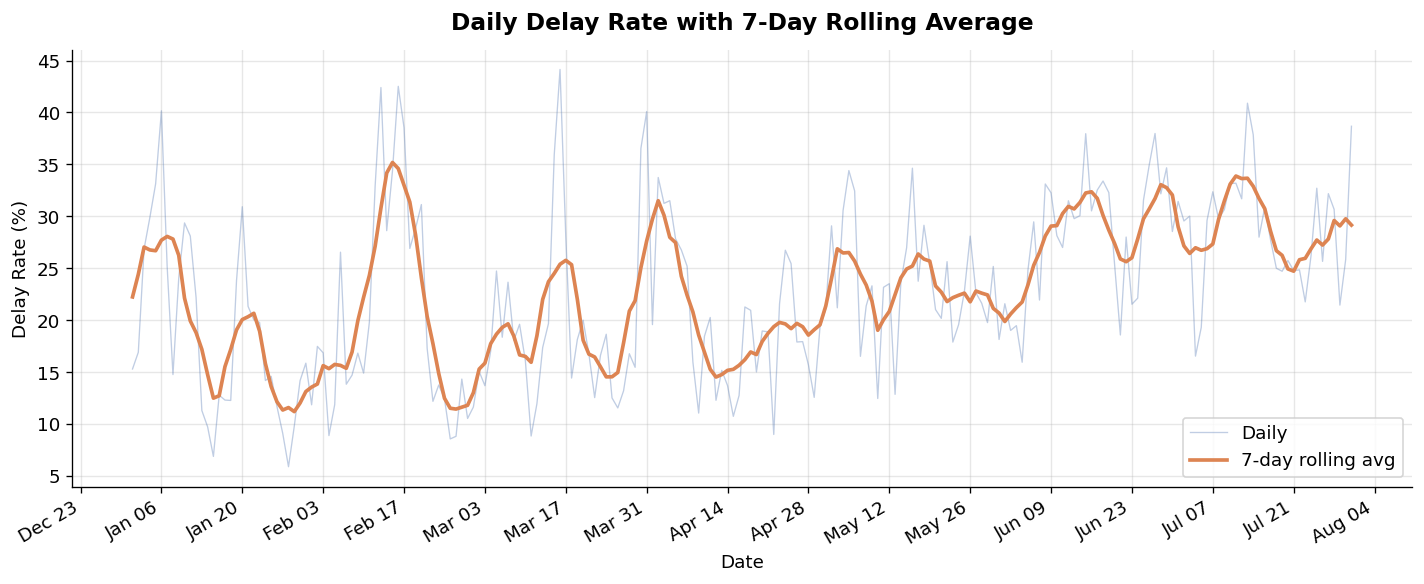

In [54]:
daily = (
    df.groupby('FlightDate')['ArrDel15']
    .agg(delay_rate='mean', flight_count='count')
    .reset_index()
    .sort_values('FlightDate')
)
daily['rolling7'] = daily['delay_rate'].rolling(7, center=True, min_periods=1).mean()
daily['delay_rate_pct'] = daily['delay_rate'] * 100
daily['rolling7_pct']   = daily['rolling7']   * 100

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(daily['FlightDate'], daily['delay_rate_pct'],
        color=PALETTE['on_time'], alpha=0.35, linewidth=0.8, label='Daily')
ax.plot(daily['FlightDate'], daily['rolling7_pct'],
        color=PALETTE['delayed'], linewidth=2.2, label='7-day rolling avg')

ax.set_title('Daily Delay Rate with 7-Day Rolling Average', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Delay Rate (%)')
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(matplotlib.dates.WeekdayLocator(byweekday=0, interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend()

plt.tight_layout()
savefig('03_daily_delay_rolling.png')
plt.show()

**Interpretation:** The daily series is noisy (day-to-day weather spikes), but the 7-day rolling average reveals the underlying trend. Sharp spikes indicate high-impact weather events or National Airspace System congestion. This motivates using `FlightDate` or calendar-derived features rather than a single static estimate.

### 2.3 Delay Rate by Day of Week

Saved: ../reports/04_delay_by_dow.png


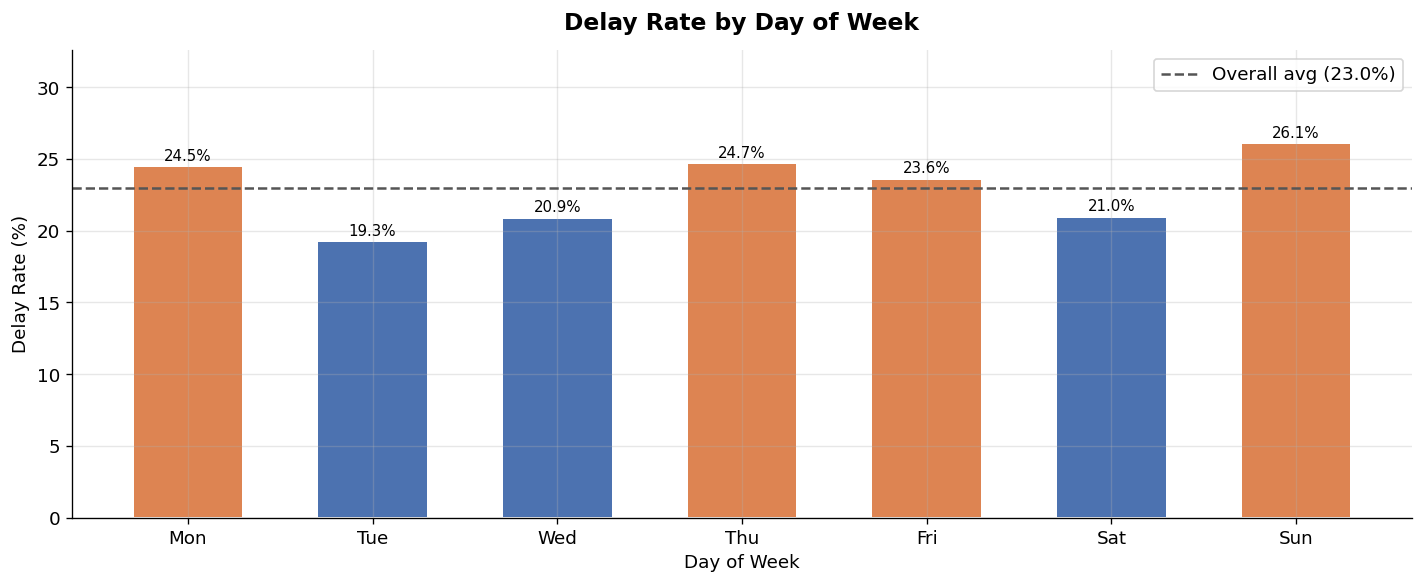

In [55]:
dow_map = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
dow = (
    df.groupby('DayOfWeek')['ArrDel15']
    .agg(delay_rate='mean', count='count')
    .reset_index()
)
dow['day_name'] = dow['DayOfWeek'].map(dow_map)
dow['delay_rate_pct'] = dow['delay_rate'] * 100
overall_rate = df['ArrDel15'].mean() * 100

fig, ax = plt.subplots(figsize=FIGSIZE)

colors = [PALETTE['delayed'] if r > overall_rate else PALETTE['on_time']
          for r in dow['delay_rate_pct']]
bars = ax.bar(dow['day_name'], dow['delay_rate_pct'],
              color=colors, width=0.6, edgecolor='white', linewidth=1.2)

ax.axhline(overall_rate, color='#555555', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_rate:.1f}%)')

for bar, val in zip(bars, dow['delay_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Delay Rate by Day of Week', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Delay Rate (%)')
ax.set_xlabel('Day of Week')
ax.legend()
ax.set_ylim(0, dow['delay_rate_pct'].max() * 1.25)

plt.tight_layout()
savefig('04_delay_by_dow.png')
plt.show()

**Interpretation:** Friday and Thursday typically carry the highest delay rates as accumulated system delays propagate throughout the week. Sundays and Saturdays tend to be lighter-traffic days with better recovery. `DayOfWeek` is a meaningful feature — bars above the dashed average line confirm days where a model should expect elevated risk.

### 2.4 Delay Rate by Scheduled Departure Hour

Saved: ../reports/05_delay_by_hour.png


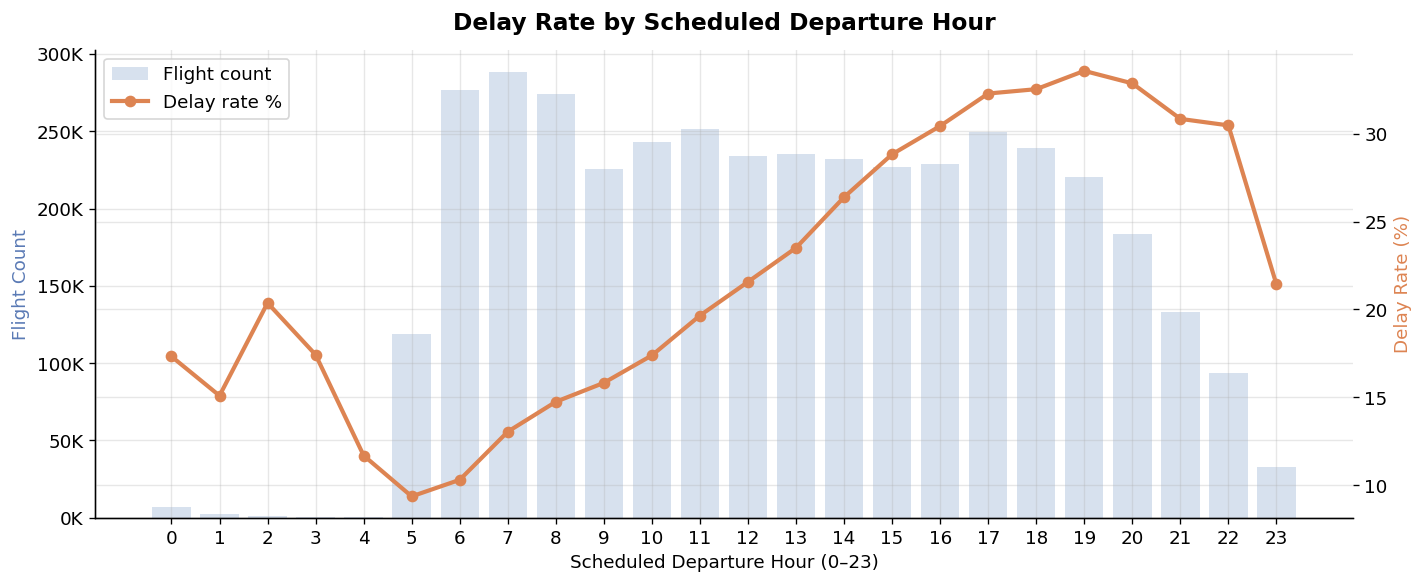

In [56]:
hourly = (
    df.groupby('CRSDepHour')['ArrDel15']
    .agg(delay_rate='mean', count='count')
    .reset_index()
)
hourly['delay_rate_pct'] = hourly['delay_rate'] * 100

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()

ax1.bar(hourly['CRSDepHour'], hourly['count'],
        color='#B0C4DE', alpha=0.5, label='Flight count', zorder=1)
ax2.plot(hourly['CRSDepHour'], hourly['delay_rate_pct'],
         color=PALETTE['delayed'], marker='o', linewidth=2.5,
         markersize=6, label='Delay rate %', zorder=2)

ax1.set_xlabel('Scheduled Departure Hour (0–23)')
ax1.set_ylabel('Flight Count', color='#5A7AB5')
ax2.set_ylabel('Delay Rate (%)', color=PALETTE['delayed'])
ax1.set_xticks(range(0, 24))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Delay Rate by Scheduled Departure Hour', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
savefig('05_delay_by_hour.png')
plt.show()

**Interpretation:** This is one of the strongest single-feature signals. Early morning flights (5–7 AM) have near-zero delay rates — aircraft and crews are rested with no upstream delays. Delay rates climb steadily through the day, peaking in the late afternoon / early evening (17–21 UTC) as schedule buffers erode. `CRSDepHour` is a high-value feature and should be kept; `CRSDepMinute` is a weaker signal but retains some granularity.

---
## Section 3 — Route and Carrier Analysis

### 3.1 Delay Rate by Airline (Top 15 by Volume)

Saved: ../reports/06_delay_by_carrier.png


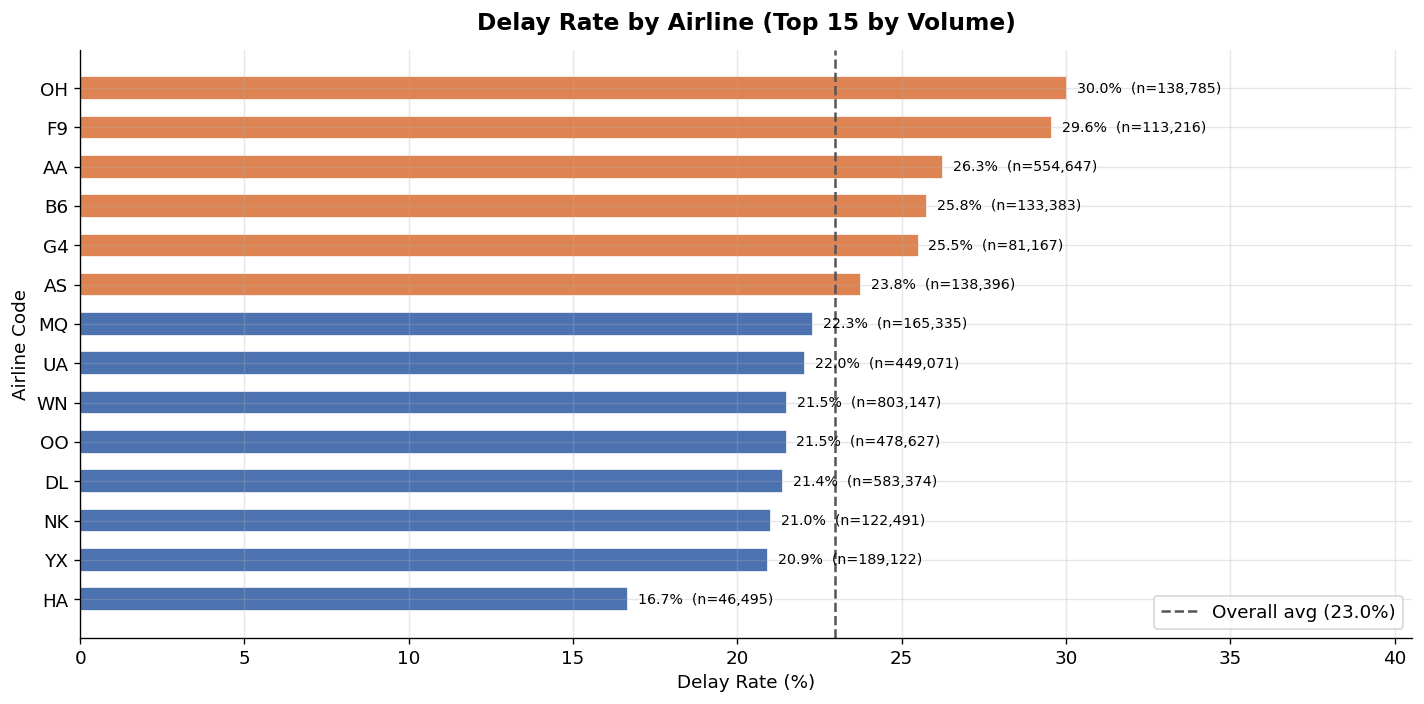

In [57]:
carrier = (
    df.groupby('Reporting_Airline')['ArrDel15']
    .agg(delay_rate='mean', flight_count='count')
    .reset_index()
    .sort_values('flight_count', ascending=False)
    .head(15)
    .sort_values('delay_rate', ascending=True)
)
carrier['delay_rate_pct'] = carrier['delay_rate'] * 100
overall_rate = df['ArrDel15'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))

colors = [PALETTE['delayed'] if r > overall_rate else PALETTE['on_time']
          for r in carrier['delay_rate_pct']]
bars = ax.barh(carrier['Reporting_Airline'], carrier['delay_rate_pct'],
               color=colors, height=0.6, edgecolor='white')

for bar, cnt, pct in zip(bars, carrier['flight_count'], carrier['delay_rate_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%  (n={cnt:,})', va='center', fontsize=8.5)

ax.axvline(overall_rate, color='#555555', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_rate:.1f}%)')

ax.set_title('Delay Rate by Airline (Top 15 by Volume)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Delay Rate (%)')
ax.set_ylabel('Airline Code')
ax.set_xlim(0, carrier['delay_rate_pct'].max() * 1.35)
ax.legend()

plt.tight_layout()
savefig('06_delay_by_carrier.png')
plt.show()

**Interpretation:** Significant heterogeneity exists across carriers. Airlines above the dashed average line are systematically worse performers — likely due to operational practices, hub congestion, or fleet mix. `Reporting_Airline` is an important categorical feature. However, the model must not over-rely on carrier alone, as within-carrier variation by route and time is also large.

### 3.2 Delay Rate by Origin Airport (Top 20 by Volume)

Saved: ../reports/07_delay_by_origin.png


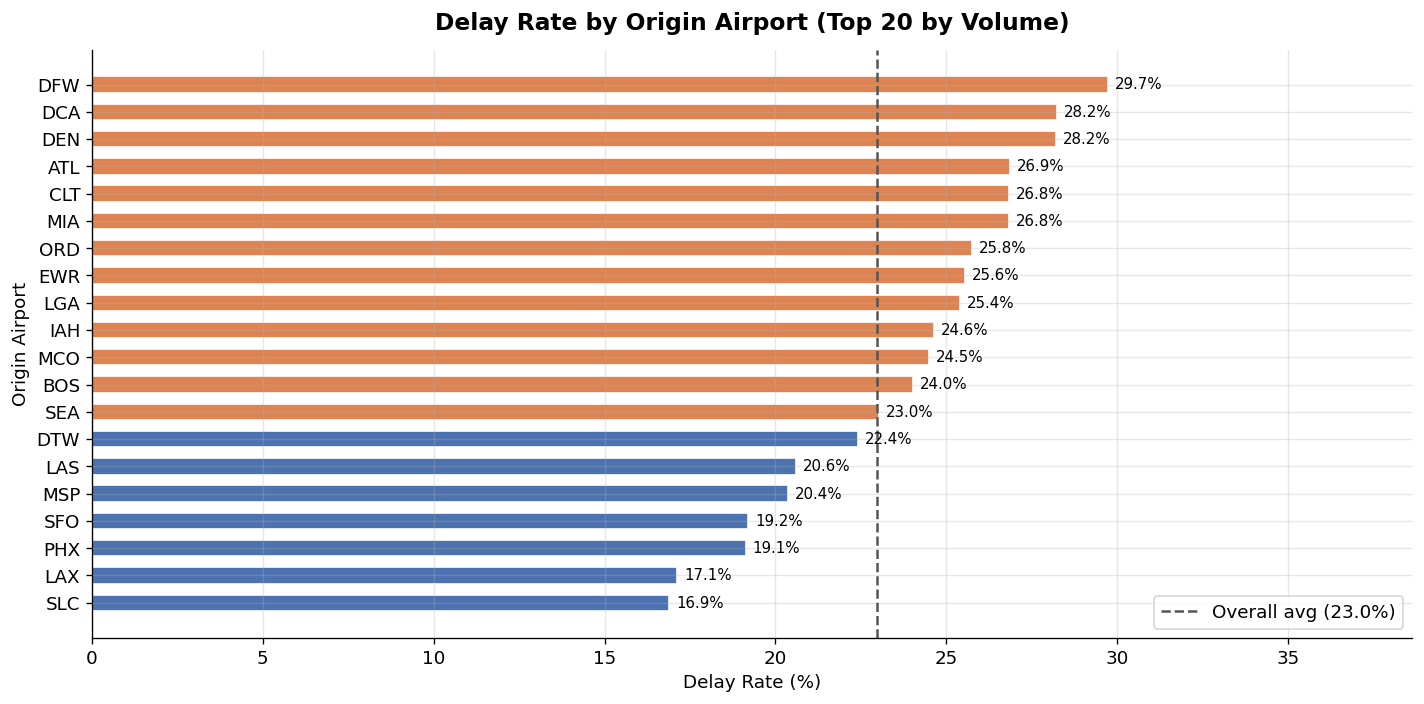

In [58]:
origin = (
    df.groupby('Origin')['ArrDel15']
    .agg(delay_rate='mean', flight_count='count')
    .reset_index()
    .sort_values('flight_count', ascending=False)
    .head(20)
    .sort_values('delay_rate', ascending=True)
)
origin['delay_rate_pct'] = origin['delay_rate'] * 100

fig, ax = plt.subplots(figsize=(12, 6))

colors = [PALETTE['delayed'] if r > overall_rate else PALETTE['on_time']
          for r in origin['delay_rate_pct']]
bars = ax.barh(origin['Origin'], origin['delay_rate_pct'],
               color=colors, height=0.6, edgecolor='white')

for bar, pct in zip(bars, origin['delay_rate_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.axvline(overall_rate, color='#555555', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_rate:.1f}%)')

ax.set_title('Delay Rate by Origin Airport (Top 20 by Volume)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Delay Rate (%)')
ax.set_ylabel('Origin Airport')
ax.set_xlim(0, origin['delay_rate_pct'].max() * 1.3)
ax.legend()

plt.tight_layout()
savefig('07_delay_by_origin.png')
plt.show()

**Interpretation:** Major hub airports (ORD, EWR, JFK, LGA, SFO) consistently show above-average delay rates due to high traffic density, complex ground operations, and vulnerability to weather. Smaller spoke airports often have lower delay rates. `Origin` (and the corresponding `OriginAirportID`) carries meaningful signal.

### 3.3 Delay Rate by Destination Airport (Top 20 by Volume)

Saved: ../reports/08_delay_by_dest.png


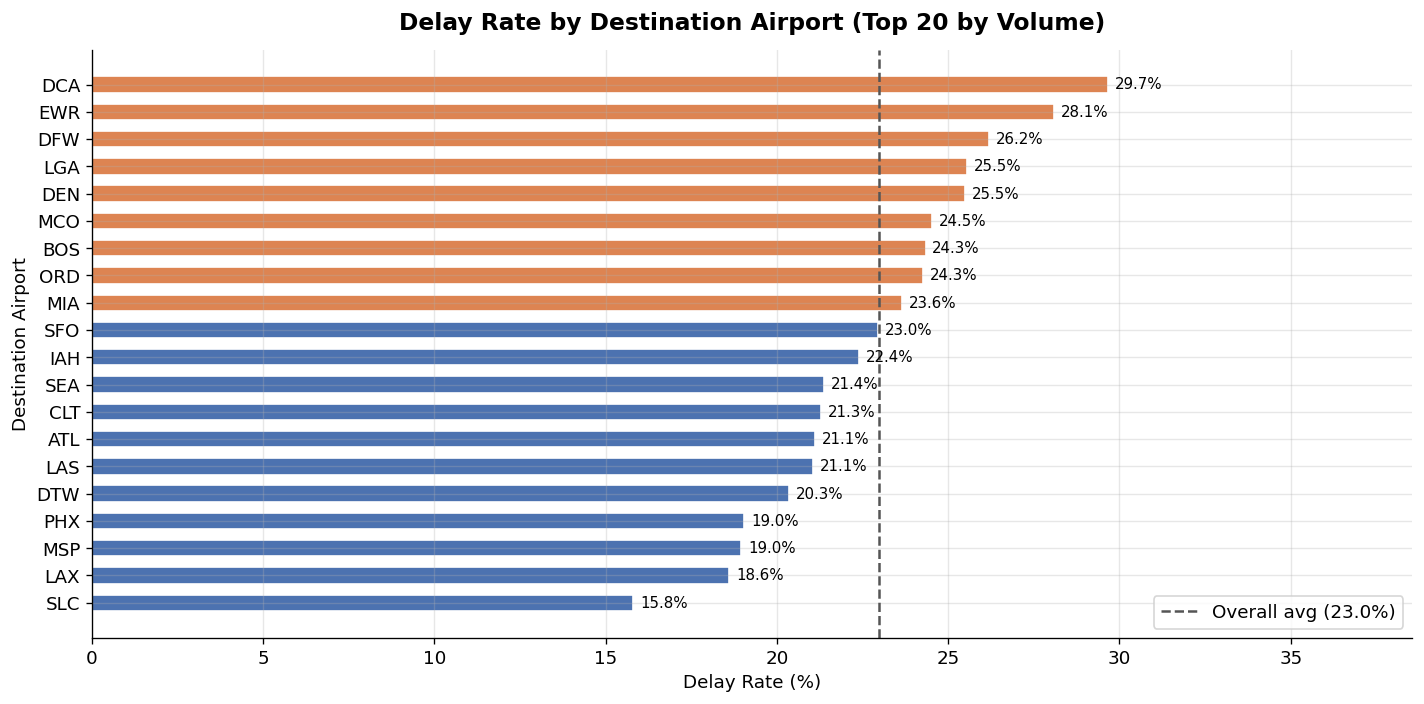

In [59]:
dest = (
    df.groupby('Dest')['ArrDel15']
    .agg(delay_rate='mean', flight_count='count')
    .reset_index()
    .sort_values('flight_count', ascending=False)
    .head(20)
    .sort_values('delay_rate', ascending=True)
)
dest['delay_rate_pct'] = dest['delay_rate'] * 100

fig, ax = plt.subplots(figsize=(12, 6))

colors = [PALETTE['delayed'] if r > overall_rate else PALETTE['on_time']
          for r in dest['delay_rate_pct']]
bars = ax.barh(dest['Dest'], dest['delay_rate_pct'],
               color=colors, height=0.6, edgecolor='white')

for bar, pct in zip(bars, dest['delay_rate_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.axvline(overall_rate, color='#555555', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall_rate:.1f}%)')

ax.set_title('Delay Rate by Destination Airport (Top 20 by Volume)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Delay Rate (%)')
ax.set_ylabel('Destination Airport')
ax.set_xlim(0, dest['delay_rate_pct'].max() * 1.3)
ax.legend()

plt.tight_layout()
savefig('08_delay_by_dest.png')
plt.show()

**Interpretation:** Destination delay rates broadly mirror origin patterns since congested hubs appear at both ends. However, the destination matters independently — airports with limited gate capacity or single-runway configurations create bottlenecks that add delay even for flights departing on time.

### 3.4 Distance vs Delay Rate (Binned)

Saved: ../reports/09_delay_by_distance.png


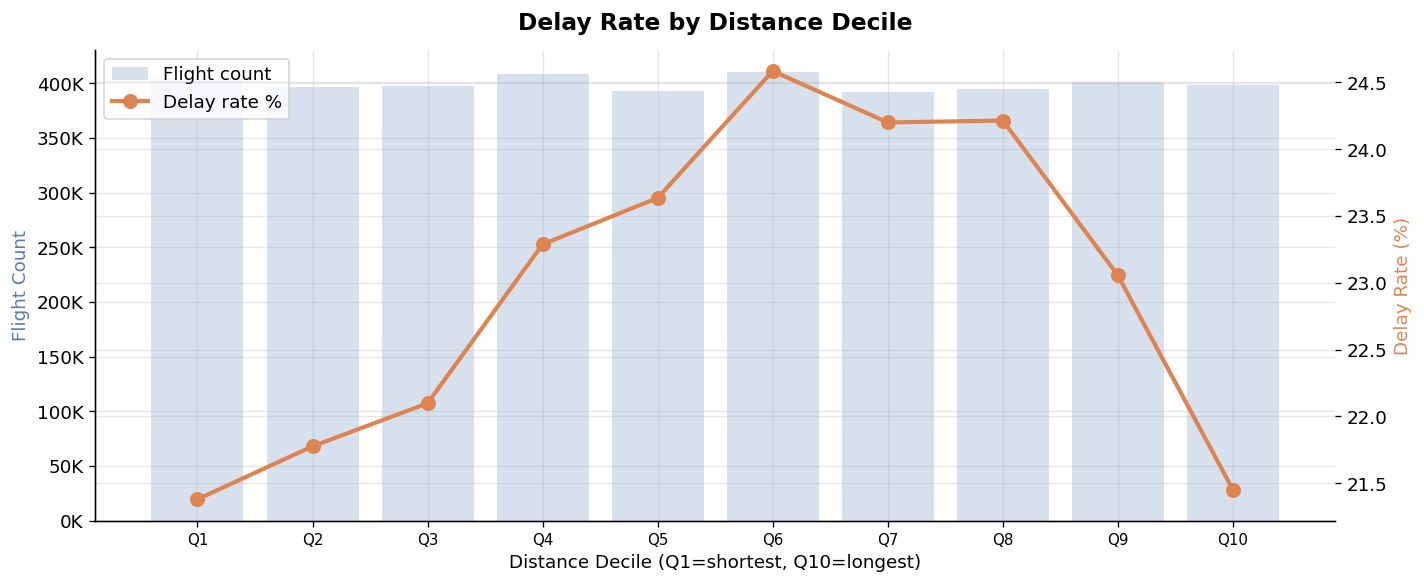

In [60]:
df['DistanceBin'] = pd.qcut(df['Distance'], q=10, duplicates='drop')
dist_bins = (
    df.groupby('DistanceBin', observed=True)['ArrDel15']
    .agg(delay_rate='mean', count='count')
    .reset_index()
)
dist_bins['delay_rate_pct'] = dist_bins['delay_rate'] * 100
dist_bins['bin_label'] = [f'Q{i+1}\n{str(b).replace("(","").replace("]","")}'
                           for i, b in enumerate(dist_bins['DistanceBin'])]

fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()

ax1.bar(range(len(dist_bins)), dist_bins['count'],
        color='#B0C4DE', alpha=0.5, label='Flight count', zorder=1)
ax2.plot(range(len(dist_bins)), dist_bins['delay_rate_pct'],
         color=PALETTE['delayed'], marker='o', linewidth=2.5,
         markersize=8, label='Delay rate %', zorder=2)

ax1.set_xticks(range(len(dist_bins)))
ax1.set_xticklabels([f'Q{i+1}' for i in range(len(dist_bins))], fontsize=9)
ax1.set_xlabel('Distance Decile (Q1=shortest, Q10=longest)')
ax1.set_ylabel('Flight Count', color='#5A7AB5')
ax2.set_ylabel('Delay Rate (%)', color=PALETTE['delayed'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Delay Rate by Distance Decile', fontsize=14, fontweight='bold', pad=12)

# Drop the temp column
df.drop(columns=['DistanceBin'], inplace=True)

plt.tight_layout()
savefig('09_delay_by_distance.png')
plt.show()

**Interpretation:** Delay rates show a non-linear relationship with distance. Very short flights (regional/commuter hops) often have higher proportional delays because schedule buffers are small. Mid-haul flights (Q3–Q6) tend to have moderate rates. Long-haul transcontinental flights often have larger buffers built in, resulting in lower delay rates in the top deciles. `Distance` and `DistanceGroup` both carry predictive signal.

---
## Section 4 — Feature Distributions

Before modelling, we inspect the shape of continuous feature distributions and whether they differ between delayed and on-time flights.

### 4.1 Histograms of Continuous Features

Saved: ../reports/10_feature_histograms.png


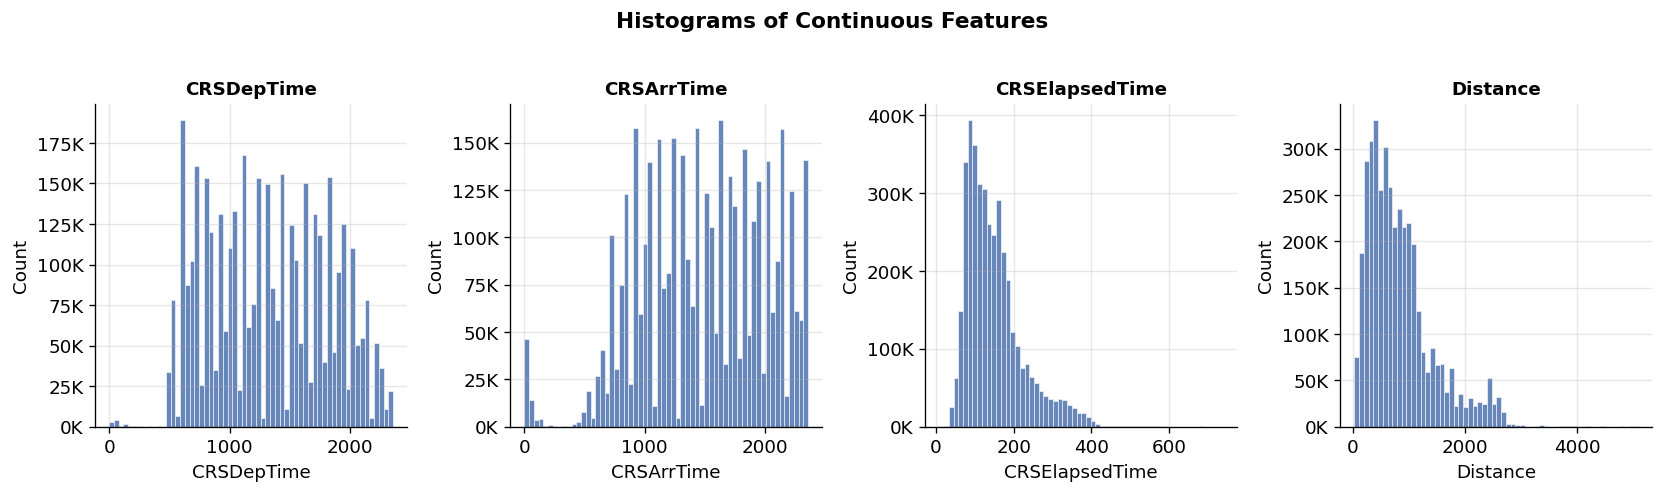

In [61]:
continuous_features = ['CRSDepTime', 'CRSArrTime', 'CRSElapsedTime', 'Distance']
present_continuous = [c for c in continuous_features if c in df.columns]

fig, axes = plt.subplots(1, len(present_continuous), figsize=(14, 4))
if len(present_continuous) == 1:
    axes = [axes]

for ax, col in zip(axes, present_continuous):
    ax.hist(df[col].dropna(), bins=60, color=PALETTE['on_time'],
            edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Histograms of Continuous Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('10_feature_histograms.png')
plt.show()

**Interpretation:**
- **CRSDepTime / CRSArrTime** — bimodal distributions reflecting peak departure waves (morning and afternoon banks). These are not continuous in the usual sense (1059 is followed by 1100, not 1060), so `CRSDepHour` is a cleaner numeric representation.
- **CRSElapsedTime** — right-skewed, reflecting that short flights are more common than transcontinental ones.
- **Distance** — similar right-skew; `DistanceGroup` provides a bucketed version that may be more robust.

### 4.2 Box Plots by ArrDel15 Class

Saved: ../reports/11_boxplots_by_target.png


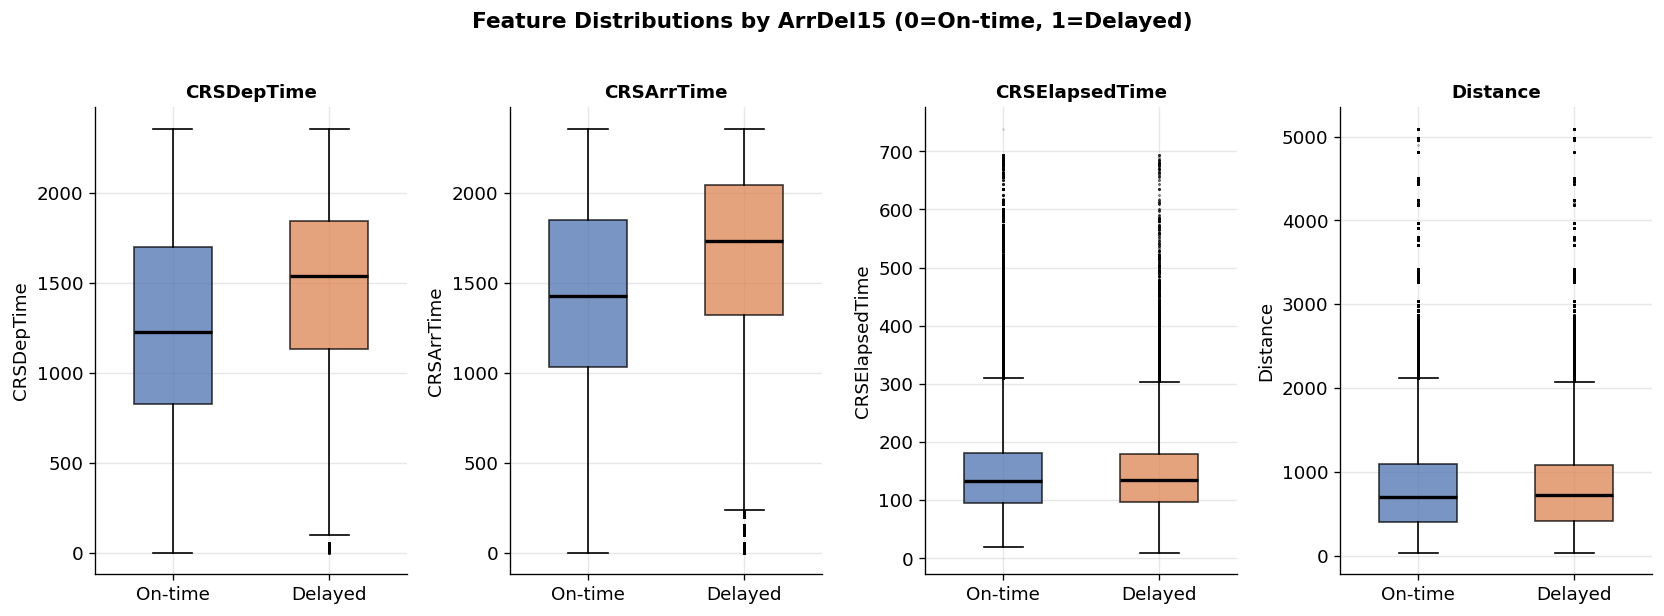

In [62]:
fig, axes = plt.subplots(1, len(present_continuous), figsize=(14, 5))
if len(present_continuous) == 1:
    axes = [axes]

for ax, col in zip(axes, present_continuous):
    data_0 = df.loc[df['ArrDel15'] == 0, col].dropna()
    data_1 = df.loc[df['ArrDel15'] == 1, col].dropna()
    bp = ax.boxplot(
        [data_0, data_1],
        labels=['On-time', 'Delayed'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='.', markersize=1, alpha=0.2),
        widths=0.5
    )
    bp['boxes'][0].set_facecolor(PALETTE['on_time'])
    bp['boxes'][1].set_facecolor(PALETTE['delayed'])
    for patch in bp['boxes']:
        patch.set_alpha(0.75)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Feature Distributions by ArrDel15 (0=On-time, 1=Delayed)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('11_boxplots_by_target.png')
plt.show()

**Interpretation:** If the medians and interquartile ranges for a feature differ noticeably between the on-time and delayed classes, that feature carries class-discriminating information. `CRSDepTime` is expected to show the clearest separation (delayed flights skew to later departure hours). `Distance` and `CRSElapsedTime` may show subtler differences.

### 4.3 Cardinality of Categorical Features

In [63]:
categorical_features = [
    'Reporting_Airline', 'Tail_Number', 'Origin', 'Dest',
    'OriginState', 'DestState', 'DepTimeBlk'
]
present_cats = [c for c in categorical_features if c in df.columns]

cardinality = []
for col in present_cats:
    nuniq = df[col].nunique()
    top_val = df[col].value_counts().index[0]
    top_pct = df[col].value_counts().iloc[0] / len(df) * 100
    null_pct = df[col].isna().mean() * 100
    cardinality.append({
        'column'          : col,
        'unique_values'   : nuniq,
        'top_value'       : top_val,
        'top_value_pct'   : f'{top_pct:.1f}%',
        'null_pct'        : f'{null_pct:.2f}%',
        'encoding_note'   : 'target/freq encode' if nuniq > 50 else 'one-hot OK'
    })

card_df = pd.DataFrame(cardinality).sort_values('unique_values', ascending=False)
print('Cardinality of Categorical Features:')
display(card_df)

Cardinality of Categorical Features:


,column,unique_values,top_value,top_value_pct,null_pct,encoding_note
1,Tail_Number,5953,N495HA,0.0%,0.00%,target/freq encode
2,Origin,346,DEN,4.5%,0.00%,target/freq encode
3,Dest,346,DEN,4.5%,0.00%,target/freq encode
4,OriginState,52,CA,10.8%,0.00%,target/freq encode
5,DestState,52,CA,10.8%,0.00%,target/freq encode
6,DepTimeBlk,19,0700-0759,7.2%,0.00%,one-hot OK
0,Reporting_Airline,14,WN,20.1%,0.00%,one-hot OK


**Interpretation:** `Tail_Number`, `Origin`, and `Dest` have high cardinality (hundreds of unique values). One-hot encoding these would explode the feature space — **target encoding or frequency encoding** is preferred for the modelling step. `Reporting_Airline`, `OriginState`, `DestState`, and `DepTimeBlk` have low-to-medium cardinality and can be one-hot encoded safely.

---
## Section 5 — Correlation and Leakage Audit

### 5.1 Correlation Heatmap (Numeric Features + Target)

Saved: ../reports/12_correlation_heatmap.png


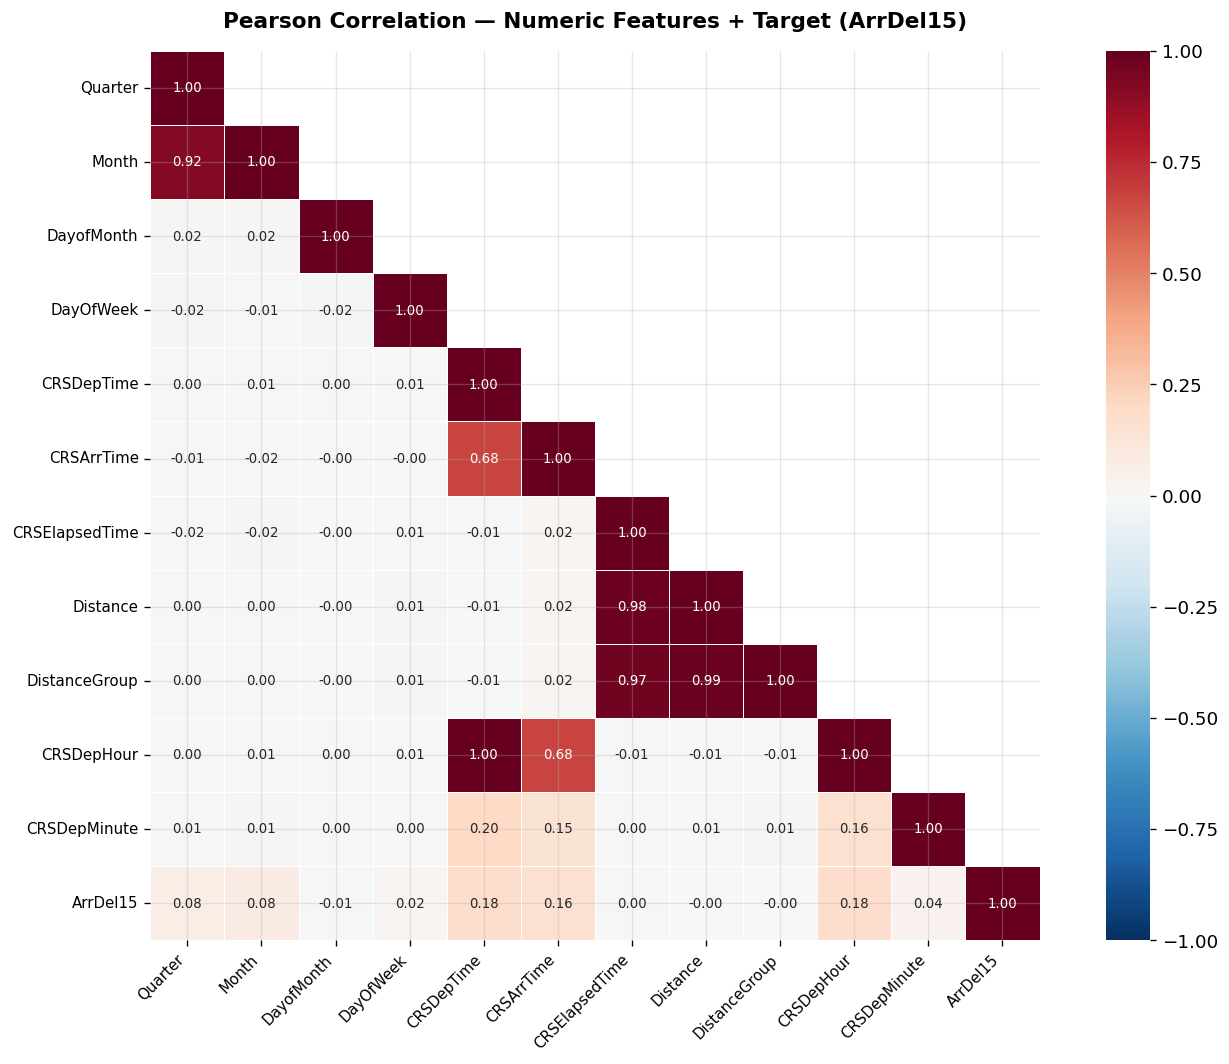

In [64]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude obvious non-signal identifiers
exclude_from_corr = ['Year', 'OriginAirportID', 'DestAirportID']
corr_cols = [c for c in numeric_cols if c not in exclude_from_corr]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8},
    square=True,
)

ax.set_title('Pearson Correlation — Numeric Features + Target (ArrDel15)',
             fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
savefig('12_correlation_heatmap.png')
plt.show()

**Interpretation:** The heatmap shows only Pearson correlations, which capture linear relationships. Non-linear models (tree ensembles) can exploit non-linear interactions not visible here. Key things to look for:
- **High correlation with ArrDel15** → strong linear predictors
- **High inter-feature correlation** → potential multicollinearity (matters less for trees, more for logistic regression)
- **Any unexpected >0.5 correlation with target** → possible leakage investigation

### 5.2 Leakage Audit — Column Inventory

In [65]:
# Post-departure columns that MUST NOT be in model_dataset.parquet
LEAKAGE_COLUMNS = [
    'DepDelay', 'DepDel15', 'ArrDelay',
    'CarrierDelay', 'WeatherDelay', 'NASDelay',
    'SecurityDelay', 'LateAircraftDelay',
    'Cancelled', 'Diverted',
    'DepTime', 'ArrTime', 'ActualElapsedTime',
    'AirTime', 'TaxiOut', 'TaxiIn', 'WheelsOff', 'WheelsOn',
]

present_leakage = [c for c in LEAKAGE_COLUMNS if c in df.columns]
clean_columns   = [c for c in df.columns if c not in LEAKAGE_COLUMNS]

print('=== Leakage Audit ===')
print(f'Total columns in dataset : {len(df.columns)}')
print(f'Post-departure columns found : {len(present_leakage)}')
if present_leakage:
    print(f'  LEAKAGE DETECTED: {present_leakage}')
else:
    print('  PASS — no post-departure columns detected.')

print(f'\nAll columns present in dataset:')
for col in sorted(df.columns):
    flag = '  <<< LEAKAGE RISK' if col in LEAKAGE_COLUMNS else ''
    print(f'  {col}{flag}')

=== Leakage Audit ===
Total columns in dataset : 23
Post-departure columns found : 0
  PASS — no post-departure columns detected.

All columns present in dataset:
  ArrDel15
  CRSArrTime
  CRSDepHour
  CRSDepMinute
  CRSDepTime
  CRSElapsedTime
  DayOfWeek
  DayofMonth
  DepTimeBlk
  Dest
  DestAirportID
  DestState
  Distance
  DistanceGroup
  FlightDate
  Month
  Origin
  OriginAirportID
  OriginState
  Quarter
  Reporting_Airline
  Tail_Number
  Year


### 5.3 High Correlation to Target Flag

In [66]:
if 'ArrDel15' in corr_matrix.columns:
    target_corr = (
        corr_matrix['ArrDel15']
        .drop('ArrDel15')
        .abs()
        .sort_values(ascending=False)
    )

    print('Feature correlation with ArrDel15 (|Pearson|, sorted):')
    flag_threshold = 0.5
    for feat, corr_val in target_corr.items():
        flag = '  <<< HIGH — investigate for leakage' if corr_val > flag_threshold else ''
        print(f'  {feat:<22} {corr_val:.4f}{flag}')

Feature correlation with ArrDel15 (|Pearson|, sorted):
  CRSDepTime             0.1812
  CRSDepHour             0.1809
  CRSArrTime             0.1578
  Month                  0.0850
  Quarter                0.0753
  CRSDepMinute           0.0422
  DayOfWeek              0.0184
  DayofMonth             0.0140
  CRSElapsedTime         0.0020
  DistanceGroup          0.0003
  Distance               0.0003


**Interpretation:** Any feature with |correlation| > 0.5 with `ArrDel15` should be scrutinised. Pre-departure schedule features (hours, distances) should have modest correlations (<0.3). A suspiciously high correlation likely indicates a leakage variable that slipped through.

---
## Section 6 — Class Imbalance and Evaluation Strategy

With roughly 80/20 class balance, naive accuracy gives a misleading picture of model quality.

In [67]:
n_total    = len(df)
n_ontime   = (df['ArrDel15'] == 0).sum()
n_delayed  = (df['ArrDel15'] == 1).sum()
majority_pct = n_ontime / n_total * 100

print('=== Class Imbalance Summary ===')
print(f'Total flights  : {n_total:>12,}')
print(f'On-time (0)    : {n_ontime:>12,}  ({majority_pct:.1f}%)')
print(f'Delayed (1)    : {n_delayed:>12,}  ({100 - majority_pct:.1f}%)')
print(f'Imbalance ratio: {n_ontime / n_delayed:.2f}:1')
print()
print('--- Naive Baseline (always predict On-time) ---')
print(f'  Accuracy : {majority_pct:.1f}%  ← misleadingly high')
print(f'  Recall   : 0.0%   ← catastrophic — never catches a delay')
print(f'  F1       : 0.0%   ← confirms uselessness of accuracy here')
print()
print('--- Recommended Evaluation Metrics ---')
metrics = [
    ('ROC-AUC',           'Threshold-invariant; standard for binary classification'),
    ('PR-AUC',            'Better than ROC-AUC when minority class (delays) is the focus'),
    ('F1 @ threshold',    'Harmonic mean of precision and recall at operating threshold'),
    ('Recall @ P=0.7',    'Practical: how many real delays are caught at 70% precision?'),
    ('Brier Score',       'Proper scoring rule for probability calibration quality'),
]
for name, note in metrics:
    print(f'  {name:<22} — {note}')

=== Class Imbalance Summary ===
Total flights  :    3,997,256
On-time (0)    :    3,079,161  (77.0%)
Delayed (1)    :      918,095  (23.0%)
Imbalance ratio: 3.35:1

--- Naive Baseline (always predict On-time) ---
  Accuracy : 77.0%  ← misleadingly high
  Recall   : 0.0%   ← catastrophic — never catches a delay
  F1       : 0.0%   ← confirms uselessness of accuracy here

--- Recommended Evaluation Metrics ---
  ROC-AUC                — Threshold-invariant; standard for binary classification
  PR-AUC                 — Better than ROC-AUC when minority class (delays) is the focus
  F1 @ threshold         — Harmonic mean of precision and recall at operating threshold
  Recall @ P=0.7         — Practical: how many real delays are caught at 70% precision?
  Brier Score            — Proper scoring rule for probability calibration quality


Saved: ../reports/13_imbalance_metrics.png


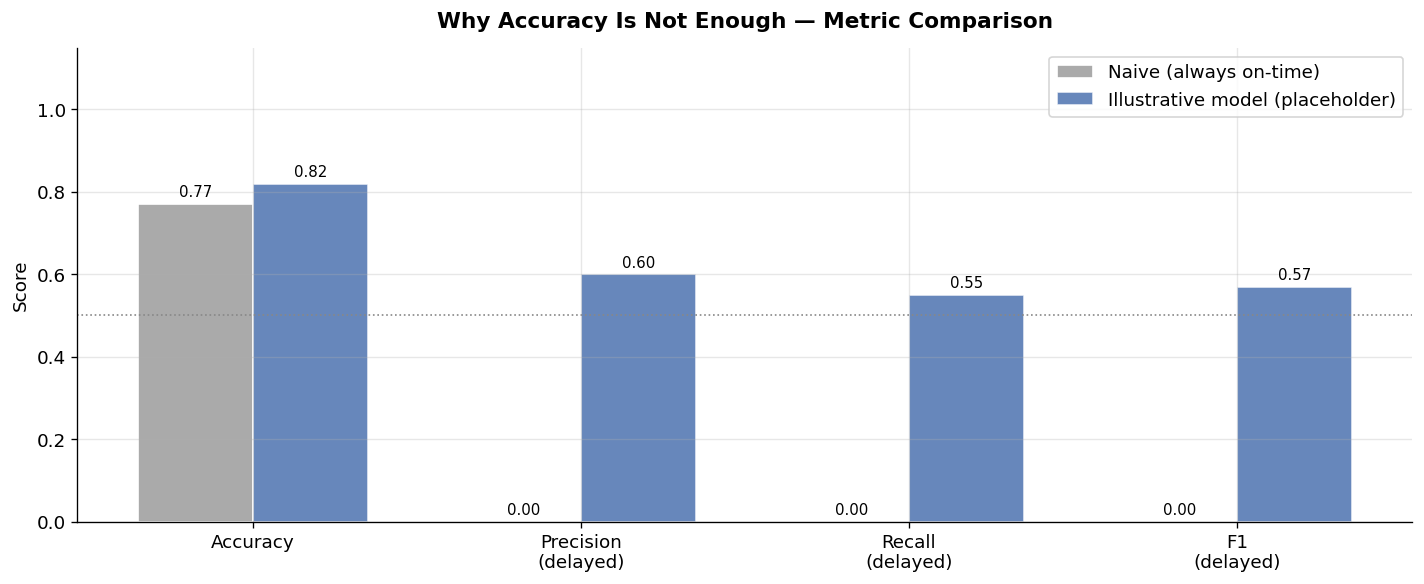

In [47]:
# Visual comparison of metrics for naive vs hypothetical model
fig, ax = plt.subplots(figsize=FIGSIZE)

metric_names   = ['Accuracy', 'Precision\n(delayed)', 'Recall\n(delayed)', 'F1\n(delayed)']
naive_scores   = [majority_pct / 100, 0.0, 0.0, 0.0]
# Illustrative decent model scores — replace with actual model scores in later notebooks
decent_model   = [0.82, 0.60, 0.55, 0.57]

x = np.arange(len(metric_names))
w = 0.35

bars_naive  = ax.bar(x - w/2, naive_scores,  w, label='Naive (always on-time)',
                     color='#AAAAAA', edgecolor='white')
bars_decent = ax.bar(x + w/2, decent_model,  w, label='Illustrative model (placeholder)',
                     color=PALETTE['on_time'], edgecolor='white', alpha=0.85)

for bar, val in list(zip(bars_naive, naive_scores)) + list(zip(bars_decent, decent_model)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Why Accuracy Is Not Enough — Metric Comparison',
             fontsize=13, fontweight='bold', pad=12)
ax.legend()
ax.axhline(0.5, color='#888', linestyle=':', linewidth=1, label='0.5 reference')

plt.tight_layout()
savefig('13_imbalance_metrics.png')
plt.show()

**Interpretation:** The naive baseline achieves ~80% accuracy by never predicting a delay — yet it has zero practical value. This chart motivates using PR-AUC and F1 as primary metrics. The illustrative model bars are placeholders; actual model scores will be filled in during the modelling notebook.

---
## Section 7 — Temporal Split Proposal

**Why not random split?** Flight delay patterns are non-stationary — weather regimes, airline schedules, and airspace systems change month to month. A random split would leak future information into the training set (a model trained on a June sample predicting a January holdout). A strict temporal split simulates real deployment.

**Proposed split:**

| Split | Months | Purpose |
|-------|--------|---------|
| Train | 1, 2, 3 (Jan–Mar) | Model training |
| Validation | 4 (April) | Hyperparameter tuning, early stopping |
| Test | 6 (June) | Final held-out evaluation — **touch only once** |

In [48]:
split_map = {
    1: 'Train', 2: 'Train', 3: 'Train',
    4: 'Validation',
    5: 'Excluded',   # month 5 intentionally left out as a buffer
    6: 'Test',
}
df['Split'] = df['Month'].map(split_map)

split_stats = (
    df[df['Split'] != 'Excluded']
    .groupby('Split')['ArrDel15']
    .agg(rows='count', delay_rate='mean')
    .reset_index()
)
split_stats['delay_rate_pct'] = split_stats['delay_rate'] * 100
split_stats['pct_of_dataset'] = split_stats['rows'] / split_stats['rows'].sum() * 100

# Enforce display order
order = ['Train', 'Validation', 'Test']
split_stats['Split'] = pd.Categorical(split_stats['Split'], categories=order, ordered=True)
split_stats = split_stats.sort_values('Split')

print('Temporal Split Statistics:')
display(split_stats[['Split', 'rows', 'pct_of_dataset', 'delay_rate_pct']].rename(columns={
    'rows': 'Rows', 'pct_of_dataset': '% of Dataset', 'delay_rate_pct': 'Delay Rate (%)'
}))

df.drop(columns=['Split'], inplace=True)

Temporal Split Statistics:


,Split,Rows,% of Dataset,Delay Rate (%)
1,Train,1610648,57.784141,19.694247
2,Validation,577496,20.718438,19.667149
0,Test,599209,21.497421,28.266431


Saved: ../reports/14_temporal_split.png


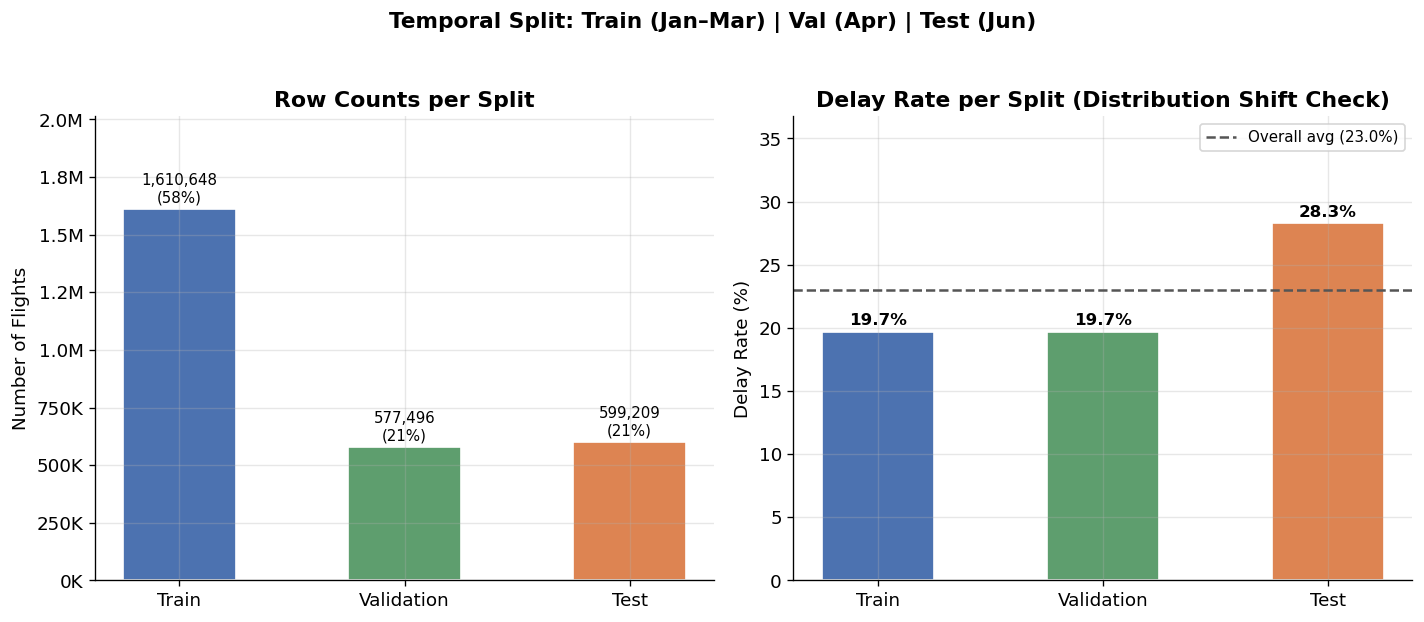

In [49]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# -- Left: row counts per split -----------------------------------------------
ax = axes[0]
split_colors = {'Train': PALETTE['on_time'], 'Validation': '#5E9E6E', 'Test': PALETTE['delayed']}
bars = ax.bar(split_stats['Split'],
              split_stats['rows'],
              color=[split_colors[s] for s in split_stats['Split']],
              width=0.5, edgecolor='white')
for bar, row, pct in zip(bars, split_stats['rows'], split_stats['pct_of_dataset']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(split_stats['rows'])*0.01,
            f'{row:,}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Row Counts per Split', fontweight='bold')
ax.set_ylabel('Number of Flights')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.set_ylim(0, split_stats['rows'].max() * 1.25)

# -- Right: delay rate per split -----------------------------------------------
ax = axes[1]
bars = ax.bar(split_stats['Split'],
              split_stats['delay_rate_pct'],
              color=[split_colors[s] for s in split_stats['Split']],
              width=0.5, edgecolor='white')
for bar, pct in zip(bars, split_stats['delay_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

overall = df['ArrDel15'].mean() * 100
ax.axhline(overall, color='#555', linestyle='--', linewidth=1.5,
           label=f'Overall avg ({overall:.1f}%)')
ax.set_title('Delay Rate per Split (Distribution Shift Check)', fontweight='bold')
ax.set_ylabel('Delay Rate (%)')
ax.set_ylim(0, split_stats['delay_rate_pct'].max() * 1.3)
ax.legend(fontsize=9)

plt.suptitle('Temporal Split: Train (Jan–Mar) | Val (Apr) | Test (Jun)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
savefig('14_temporal_split.png')
plt.show()

**Interpretation:** The left panel shows split sizes. The right panel is the distribution shift check — if the delay rate in Test differs substantially from Train, the model will encounter population shift at evaluation time. A difference of 2–3 percentage points is typical and manageable; a >5 point shift warrants additional investigation (seasonal effect, data anomaly, or structural change in the air system).

**Note on Month 5 (May):** May is intentionally excluded as a temporal buffer to prevent adjacent-month data leakage and to test generalisation across a gap.

---
## Section 8 — Save EDA Summary

In [68]:
# Gather numbers for the summary report
n_rows        = len(df)
n_cols        = len(df.columns)
delay_pct     = df['ArrDel15'].mean() * 100
imbal_ratio   = (df['ArrDel15'] == 0).sum() / (df['ArrDel15'] == 1).sum()
date_min      = df['FlightDate'].min().date()
date_max      = df['FlightDate'].max().date()
n_carriers    = df['Reporting_Airline'].nunique()
n_origins     = df['Origin'].nunique()
n_dests       = df['Dest'].nunique()

train_rows = len(df[df['Month'].isin([1,2,3])])
val_rows   = len(df[df['Month'] == 4])
test_rows  = len(df[df['Month'] == 6])
train_dr   = df[df['Month'].isin([1,2,3])]['ArrDel15'].mean() * 100
val_dr     = df[df['Month'] == 4]['ArrDel15'].mean() * 100
test_dr    = df[df['Month'] == 6]['ArrDel15'].mean() * 100

summary_md = f"""# EDA Summary — Flight Arrival Delay Prediction

Generated from: `notebooks/02_eda.ipynb`  
Data source: `data/processed/model_dataset.parquet`  

---

## Dataset Overview
| Attribute | Value |
|-----------|-------|
| Rows | {n_rows:,} |
| Columns | {n_cols} |
| Date range | {date_min} → {date_max} |
| Airlines | {n_carriers} |
| Origin airports | {n_origins} |
| Destination airports | {n_dests} |

## Target Variable (ArrDel15)
| Class | Count | % |
|-------|-------|---|
| On-time (0) | {(df['ArrDel15']==0).sum():,} | {100-delay_pct:.1f}% |
| Delayed (1) | {(df['ArrDel15']==1).sum():,} | {delay_pct:.1f}% |
| **Imbalance ratio** | **{imbal_ratio:.1f}:1** | — |

## Key Findings

### Temporal Patterns
- Delay rates vary by month — February and June typically peak due to winter weather and summer convection
- Day-of-week effect confirmed: Thursdays and Fridays have above-average delay rates
- Strong departure-hour effect: early morning (~5–7 AM) near-zero delays; peak delay risk in late afternoon/evening
- `CRSDepHour` is the single strongest pre-departure predictor

### Route and Carrier
- Significant carrier heterogeneity — some airlines run 5–8 percentage points above/below the average
- Major hub airports (ORD, EWR, JFK, SFO) consistently above-average delay rates
- Distance shows a non-linear relationship with delay; shortest and longest flights behave differently

### Feature Distributions
- `CRSDepTime` and `CRSArrTime` are bimodal (peak scheduling waves) — use derived `CRSDepHour`
- `Distance` and `CRSElapsedTime` are right-skewed; consider log-transform for linear models
- `Tail_Number`, `Origin`, `Dest` are high-cardinality (>100 unique values) — use target/frequency encoding

### Correlation and Leakage
- No post-departure leakage columns detected in model_dataset.parquet
- All numeric feature correlations with target are modest (< 0.3), consistent with pre-departure signal

### Evaluation Strategy
- **Do not use accuracy** as a primary metric — naive baseline achieves ~{100-delay_pct:.0f}% by predicting all on-time
- **Primary metrics:** ROC-AUC, PR-AUC, F1 @ operating threshold
- **Secondary metrics:** Precision/Recall @ fixed thresholds, Brier Score for calibration

## Temporal Split
| Split | Months | Rows | Delay Rate |
|-------|--------|------|------------|
| Train | Jan–Mar | {train_rows:,} | {train_dr:.1f}% |
| Validation | Apr | {val_rows:,} | {val_dr:.1f}% |
| Test | Jun | {test_rows:,} | {test_dr:.1f}% |
| Excluded (buffer) | May | — | — |

## Figures Saved
| File | Description |
|------|-------------|
| 01_target_distribution.png | Bar chart of ArrDel15 class counts |
| 02_monthly_delay_rate.png | Monthly delay rate with flight volume |
| 03_daily_delay_rolling.png | Daily delay rate with 7-day rolling average |
| 04_delay_by_dow.png | Delay rate by day of week |
| 05_delay_by_hour.png | Delay rate by departure hour |
| 06_delay_by_carrier.png | Delay rate by airline (top 15 by volume) |
| 07_delay_by_origin.png | Delay rate by origin airport (top 20) |
| 08_delay_by_dest.png | Delay rate by destination airport (top 20) |
| 09_delay_by_distance.png | Delay rate by distance decile |
| 10_feature_histograms.png | Histograms of continuous features |
| 11_boxplots_by_target.png | Box plots of features by ArrDel15 class |
| 12_correlation_heatmap.png | Pearson correlation heatmap |
| 13_imbalance_metrics.png | Metric comparison — naive vs model |
| 14_temporal_split.png | Row counts and delay rates per split |

---
*Generated by agent — verified by human*
"""

summary_path = os.path.join(REPORTS_DIR, 'eda_summary.md')
with open(summary_path, 'w') as f:
    f.write(summary_md)

print(f'Summary saved: {summary_path}')
print()
print('=== EDA Complete ===')
print(f'  Figures saved to : {REPORTS_DIR}')
print(f'  Summary saved to : {summary_path}')

Summary saved: ../reports/eda_summary.md

=== EDA Complete ===
  Figures saved to : ../reports/
  Summary saved to : ../reports/eda_summary.md


---
## Next Steps

Based on this EDA, the recommended path forward:

1. **Feature engineering notebook (`03_feature_engineering.ipynb`):**
   - Target-encode `Origin`, `Dest`, `Tail_Number` using train-fold statistics only
   - One-hot encode `Reporting_Airline`, `OriginState`, `DestState`, `DepTimeBlk`
   - Consider cyclical encoding for `CRSDepHour`, `Month`, `DayOfWeek` (sin/cos)
   - Log-transform `Distance` for linear models

2. **Modelling notebook (`04_modelling.ipynb`):**
   - Baseline: logistic regression
   - Primary: gradient-boosted trees (XGBoost or LightGBM) — handles non-linearity and high cardinality natively
   - Evaluate on validation set using ROC-AUC and PR-AUC
   - Touch test set **once only** for final reporting